In [ ]:
import requests


url = 'https://www.alphavantage.co/query?function=DIGITAL_CURRENCY_DAILY&symbol=BTC&market=USD&apikey=IMC7MNTFRJNI2QX2'
r = requests.get(url)
data = r.json()

print(data)

{'Meta Data': {'1. Information': 'Daily Prices and Volumes for Digital Currency', '2. Digital Currency Code': 'BTC', '3. Digital Currency Name': 'Bitcoin', '4. Market Code': 'USD', '5. Market Name': 'United States Dollar', '6. Last Refreshed': '2026-04-04 00:00:00', '7. Time Zone': 'UTC'}, 'Time Series (Digital Currency Daily)': {'2026-04-04': {'1. open': '66959.98000000', '2. high': '66959.99000000', '3. low': '66863.17000000', '4. close': '66945.73000000', '5. volume': '36.18548284'}, '2026-04-03': {'1. open': '66899.11000000', '2. high': '67375.70000000', '3. low': '66275.01000000', '4. close': '66959.99000000', '5. volume': '4181.03967015'}, '2026-04-02': {'1. open': '68112.34000000', '2. high': '68652.00000000', '3. low': '65696.96000000', '4. close': '66894.48000000', '5. volume': '8813.97029196'}, '2026-04-01': {'1. open': '68221.84000000', '2. high': '69285.99000000', '3. low': '67525.59000000', '4. close': '68112.35000000', '5. volume': '9804.65444480'}, '2026-03-31': {'1. ope

In [ ]:
import pandas as pd
raw= data['Time Series (Digital Currency Daily)']
raw

df = pd.DataFrame(raw).T


df.columns = [
    'open_USD', 'high_USD',
    'low_USD', 'close_USD',
    'volume'
]

df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.isnull().sum()
df = df.astype(float)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5741 entries, 2010-07-17 to 2026-04-04
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open_USD   5741 non-null   float64
 1   high_USD   5741 non-null   float64
 2   low_USD    5741 non-null   float64
 3   close_USD  5741 non-null   float64
 4   volume     5741 non-null   float64
dtypes: float64(5)
memory usage: 269.1 KB


,open_USD,high_USD,low_USD,close_USD,volume
2010-07-17,0.0500,0.0500,0.0500,0.0500,0.0
2010-07-18,0.0858,0.0858,0.0858,0.0858,0.0
2010-07-19,0.0808,0.0808,0.0808,0.0808,0.0
2010-07-20,0.0747,0.0747,0.0747,0.0747,0.0
2010-07-21,0.0792,0.0792,0.0792,0.0792,0.0


In [ ]:
df['Target_Next_Day'] = df['close_USD'].shift(-1)
df['lag1'] = df['close_USD'].shift(1)
#df['lag2'] = df['close_USD'].shift(2)
#df['lag3'] = df['close_USD'].shift(3)
#df['lag4'] = df['close_USD'].shift(4)
#df['lag5'] = df['close_USD'].shift(5)

df['ma_7'] = df['close_USD'].rolling(window=7).mean()
df['ma_30'] = df['close_USD'].rolling(window=30).mean()

df['daily_return'] = df['close_USD'].pct_change()
df['volatility_7'] = df['daily_return'].rolling(window=7).std()
df['volatility_30'] = df['daily_return'].rolling(window=30).std()

# 1. Find the highest price Bitcoin has hit in the last 30 days
rolling_max = df['close_USD'].rolling(window=30, min_periods=1).max()

# 2. Calculate how far we are below that peak (%)
df['Drawdown'] = (df['close_USD'] - rolling_max) / rolling_max

# --- 1. RSI (Relative Strength Index) ---
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss

    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['close_USD'])

# --- 2. MACD (Moving Average Convergence Divergence) ---
# MACD is the difference between a fast and a slow moving average
exp1 = df['close_USD'].ewm(span=12, adjust=False).mean() # 12-day EMA
exp2 = df['close_USD'].ewm(span=26, adjust=False).mean() # 26-day EMA
df['MACD'] = exp1 - exp2

# Signal line (9-day EMA of the MACD itself)
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# --- 3. Cleanup ---
# These indicators need 14-26 days of data to start working,
# so we drop the resulting NaN rows at the beginning.


# 1. Middle Band (20-day Moving Average)
df['MA20'] = df['close_USD'].rolling(window=20).mean()

# 2. 20-day Standard Deviation (The "Risk" measure)
df['20STD'] = df['close_USD'].rolling(window=20).std()

# 3. Upper and Lower Bands
df['Upper_Band'] = df['MA20'] + (df['20STD'] * 2)
df['Lower_Band'] = df['MA20'] - (df['20STD'] * 2)

# 4. Feature for the Model: Bollinger %B
# This normalizes the bands into a 0-to-1 scale
df['Bollinger_PercB'] = (df['close_USD'] - df['Lower_Band']) / (df['Upper_Band'] - df['Lower_Band'])

# 5. Clean up the starting NaN values
df.dropna(inplace=True)

df.head()

,open_USD,high_USD,low_USD,close_USD,volume,Target_Next_Day,lag1,ma_7,ma_30,daily_return,...,volatility_30,Drawdown,RSI,MACD,MACD_Signal,MA20,20STD,Upper_Band,Lower_Band,Bollinger_PercB
2010-08-16,0.0655,0.0655,0.0655,0.0655,0.0,0.0700,0.0653,0.067043,0.064520,0.003063,...,0.171626,-0.236597,56.790123,0.002118,0.002190,0.064050,0.004333,0.072717,0.055383,0.583655
2010-08-17,0.0700,0.0700,0.0700,0.0700,0.0,0.0680,0.0655,0.067043,0.063993,0.068702,...,0.111404,-0.133663,61.111111,0.002339,0.002220,0.064605,0.004350,0.073305,0.055905,0.810074
2010-08-18,0.0680,0.0680,0.0680,0.0680,0.0,0.0667,0.0700,0.067186,0.063567,-0.028571,...,0.111001,-0.141414,62.500000,0.002326,0.002241,0.064510,0.004248,0.073005,0.056015,0.705411
2010-08-19,0.0667,0.0667,0.0667,0.0667,0.0,0.0655,0.0680,0.066714,0.063300,-0.019118,...,0.110140,-0.157828,56.900726,0.002186,0.002230,0.064710,0.004252,0.073214,0.056206,0.617002
2010-08-20,0.0655,0.0655,0.0655,0.0655,0.0,0.0664,0.0667,0.066857,0.062843,-0.017991,...,0.109654,-0.077465,53.883495,0.001955,0.002175,0.064590,0.004191,0.072971,0.056209,0.554287


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

x= df.drop(['close_USD','Target_Next_Day', 'open_USD', 'high_USD', 'low_USD', 'Upper_Band', 'MA20',
            'Lower_Band', 'ma_7', 'MACD_Signal'], axis= 1)
y= df['Target_Next_Day']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, shuffle= False)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size= 0.2, shuffle= False)

scaler = StandardScaler()

#scaler.fit(x_train)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_val= scaler.transform(x_val)


#pca= PCA(n_components= 6)
#x_train = pca.fit_transform(x_train)
#x_test = pca.transform(x_test)
x.head()

,volume,lag1,ma_30,daily_return,volatility_7,volatility_30,Drawdown,RSI,MACD,20STD,Bollinger_PercB
2010-08-16,0.0,0.0653,0.064520,0.003063,0.043933,0.171626,-0.236597,56.790123,0.002118,0.004333,0.583655
2010-08-17,0.0,0.0655,0.063993,0.068702,0.053041,0.111404,-0.133663,61.111111,0.002339,0.004350,0.810074
2010-08-18,0.0,0.0700,0.063567,-0.028571,0.051310,0.111001,-0.141414,62.500000,0.002326,0.004248,0.705411
2010-08-19,0.0,0.0680,0.063300,-0.019118,0.048286,0.110140,-0.157828,56.900726,0.002186,0.004252,0.617002
2010-08-20,0.0,0.0667,0.062843,-0.017991,0.037253,0.109654,-0.077465,53.883495,0.001955,0.004191,0.554287


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear') # Linear output for price prediction
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20753798.0000 - mae: 2601.7583 - val_loss: 5514457600.0000 - val_mae: 67975.3984
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20040054.0000 - mae: 2554.8257 - val_loss: 5165599744.0000 - val_mae: 65711.0312
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17065596.0000 - mae: 2364.7620 - val_loss: 4124660480.0000 - val_mae: 58453.4492
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11258474.0000 - mae: 1944.4921 - val_loss: 2509683200.0000 - val_mae: 44978.2461
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5100380.0000 - mae: 1352.1477 - val_loss: 1121179776.0000 - val_mae: 28841.0156
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1836092.2500 - mae: 830.3518 - val_loss: 473651392.0000 - val_mae: 17180.4473
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1019507.3750 - mae: 632.4926 - val_loss: 286788992.0000 - val_mae: 12840.8125
Epoch 8/50
115/115 ━━━━━━━━━━━━

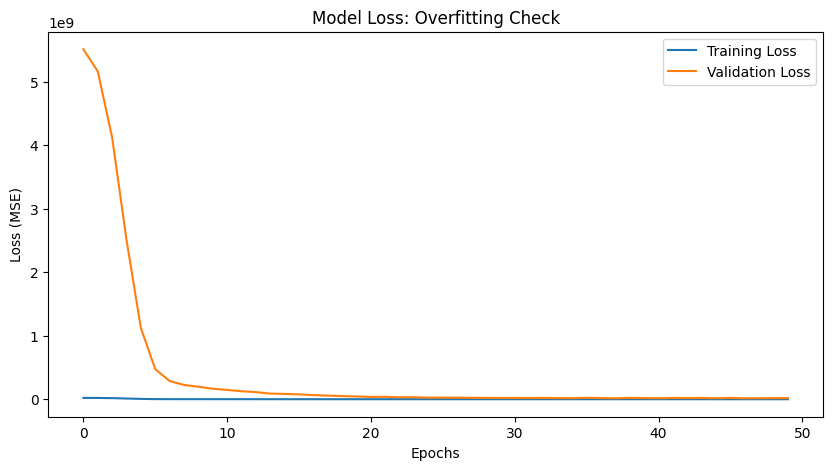

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss: Overfitting Check')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


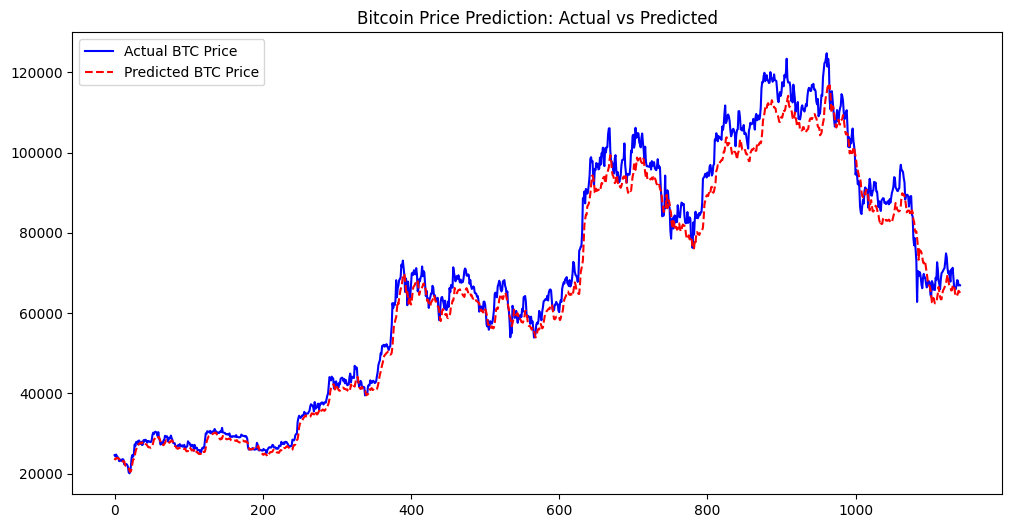

In [ ]:
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual BTC Price', color='blue')
plt.plot(predictions, label='Predicted BTC Price', color='red', linestyle='--')
plt.title('Bitcoin Price Prediction: Actual vs Predicted')
plt.legend()
plt.show()

                   volume      lag1     ma_30  daily_return  volatility_7  \
volume           1.000000  0.414875  0.400764     -0.025921     -0.068575   
lag1             0.414875  1.000000  0.995633     -0.042989     -0.200180   
ma_30            0.400764  0.995633  1.000000     -0.042798     -0.196505   
daily_return    -0.025921 -0.042989 -0.042798      1.000000      0.091282   
volatility_7    -0.068575 -0.200180 -0.196505      0.091282      1.000000   
volatility_30   -0.140224 -0.282778 -0.280914      0.061020      0.724592   
Drawdown         0.082453  0.147156  0.111767      0.249756     -0.447866   
RSI             -0.009230 -0.049520 -0.093386      0.276010     -0.020910   
MACD             0.225659  0.133913  0.048568      0.033765     -0.046578   
20STD            0.549596  0.799292  0.794956     -0.028100     -0.056840   
Bollinger_PercB -0.010625 -0.052090 -0.093082      0.387909     -0.033233   

                 volatility_30  Drawdown       RSI      MACD     20STD  \
v

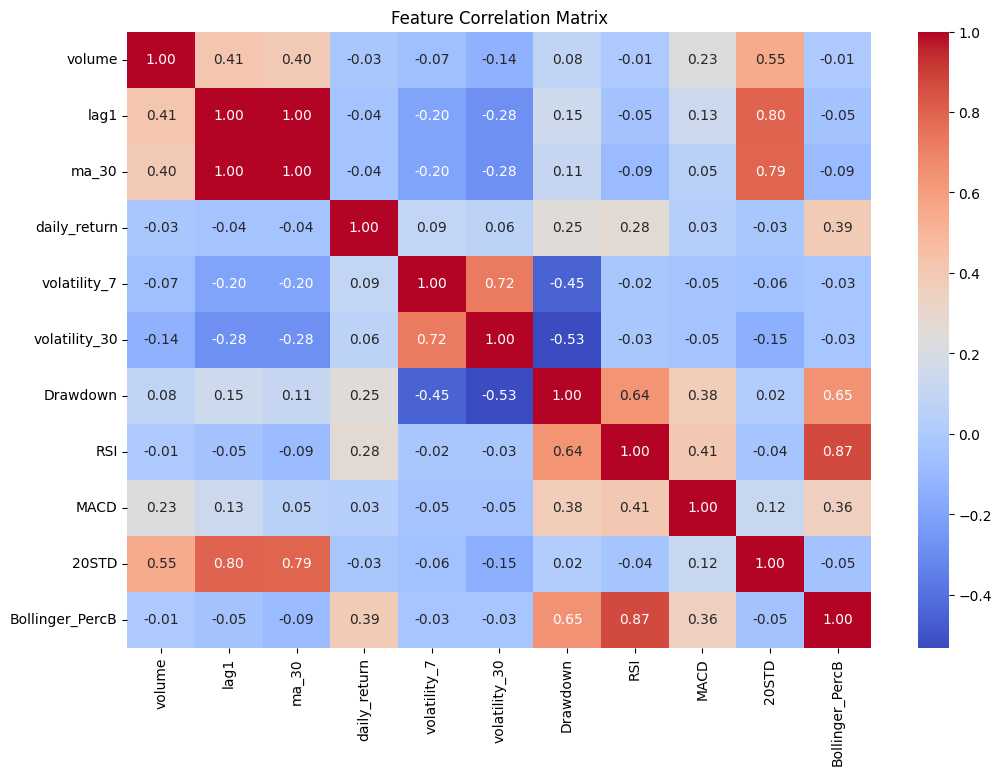

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = x.corr(numeric_only=True)

# Print it
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

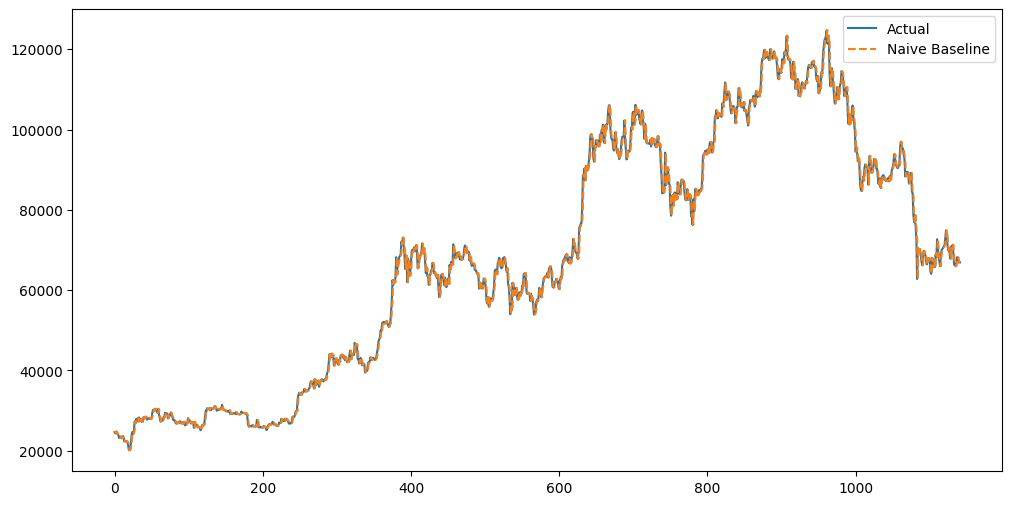

In [ ]:
# Naive baseline: tomorrow = today
# The y_test values are 'Target_Next_Day', which means tomorrow's close price.
# A naive baseline predicts tomorrow's price as today's close price.
# So, we need the 'close_USD' from the original df for the dates corresponding to y_test.
baseline = df.loc[y_test.index, 'close_USD']

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(baseline.values, label='Naive Baseline', linestyle='--')
plt.legend()
plt.show()

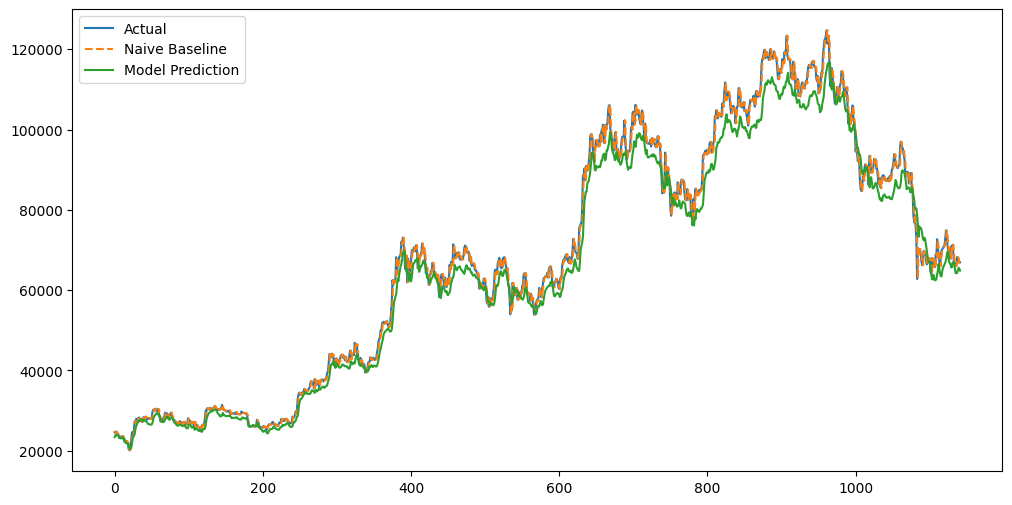

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(baseline.values, label='Naive Baseline', linestyle='--')
plt.plot(predictions, label='Model Prediction')

plt.legend()
plt.show()